# Introduction

The goal of this project is to predict the trip duration of any given taxi ride. We will be taking into consideration various data points including: distance, pickup & drop-off location, month & time of day, and number of passangers. This is useful to both users and taxi companies to know and understand the different factors in how long a taxi ride will take. 

We will be analyzing three machine learning models and comparing their results to find an optimal model. The models used are:
- [Random Forest Regression](#random-forest-regression)
- [Gradient Boosting Model (XGBoost)](#gradient-boosting-model-xgboost)
- [Deep Learning](#deep-learning)

# Packages & Imports
The cell below lists all the libraries we plan on importing for use in this project.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from geodatasets import get_path

from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib.pyplot as plt

import folium as fm
from folium.plugins import FastMarkerCluster

from shapely.geometry import Point

# The Data
*Data provided for by Kaggle (2016)

The data is gathered in the following:
- **id**: unique identifier for each trip
- **vendor_id**: a code indicating the provider associated with the trip recorded
- **pickup_datetime**: date and time when the meter was engaged
- **dropoff_datetime**: date and time when the meter was disengaged
- **passenger_count**: number of passangers in the vehicle
- **pickup_longitude**: longitude where meter was engaged
- **pickup_latitude**: latitude where meter was engaged
- **dropoff_longitude**: longitude where the meter was disengaged
- **dropoff_latitude**: latitude where the meter was disengaged
- **store_and_fwd_flag**: whether the trip was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server
- **trip_duration**: duration of the trip in seconds


In [2]:
dataset = pd.read_csv('data/train.csv')
dataset.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# Dropping of Data Features

* **id:** Unique to each ride so will not be helpful in our model.
* **dropoff_datetime:** This feature is not necessary becuase we don't care about dropoff information since we already have trip duration and dropoff location. 
* **store_and_fwd_flag:** There is no correlation between this feature and time duartion. 

In [3]:
# Drop unnecessary columns
dataset = dataset.drop(columns=['id', 'dropoff_datetime', 'store_and_fwd_flag'])

# Transform Date and Time

In [4]:
# Reformat the pickup_datetime column to pickup_hour & pickup_day_of_the_week and remove dropoff_datetime column
dataset['pickup_hour'] = pd.to_datetime(dataset['pickup_datetime']).dt.hour
dataset['pickup_day_of_the_week'] = pd.to_datetime(dataset['pickup_datetime']).dt.dayofweek

dataset = dataset.drop(columns=['pickup_datetime'])

dataset.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_day_of_the_week
0,2,1,-73.982155,40.767937,-73.964630,40.765602,455,17,0
1,1,1,-73.980415,40.738564,-73.999481,40.731152,663,0,6
2,2,1,-73.979027,40.763939,-74.005333,40.710087,2124,11,1
3,2,1,-74.010040,40.719971,-74.012268,40.706718,429,19,2
4,2,1,-73.973053,40.793209,-73.972923,40.782520,435,13,5


# Filter Pickup Points within NYC Boundaries

In [5]:
# Limit longitude and latitude to the area of NYC
dataset = dataset[(dataset['pickup_longitude'] >= -74.05) & (dataset['pickup_longitude'] <= -73.75)]
dataset = dataset[(dataset['pickup_latitude'] >= 40.48) & (dataset['pickup_latitude'] <= 40.92)]

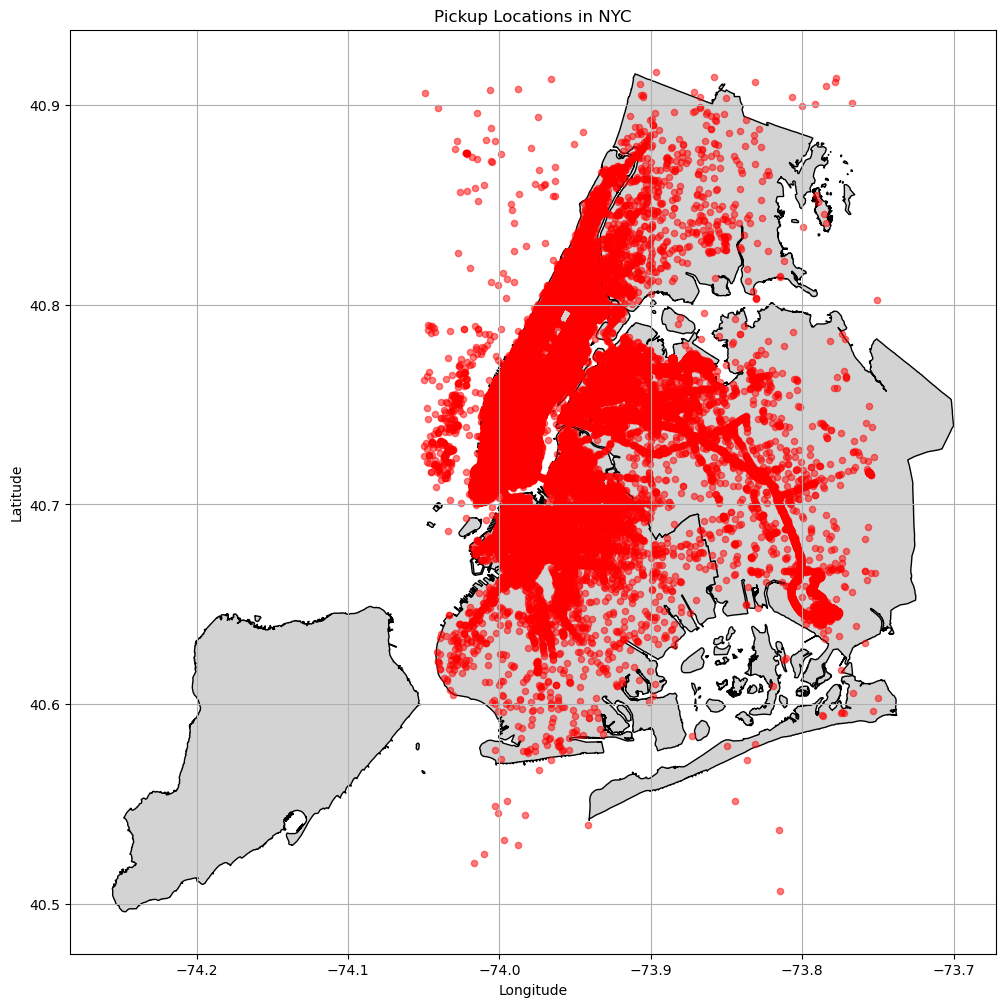

In [6]:
gdf = gpd.GeoDataFrame(dataset, geometry=gpd.points_from_xy(dataset['pickup_longitude'], dataset['pickup_latitude']), crs='EPSG:4326')

nyc_path = get_path('nybb')
nyc = gpd.read_file(nyc_path)
nyc = nyc.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12, 12))
nyc.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.5)
plt.title('Pickup Locations in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [7]:
# Limit longitude and latitude to the area of NYC
dataset = dataset[(dataset['dropoff_longitude'] >= -74.05) & (dataset['dropoff_longitude'] <= -73.75)]
dataset = dataset[(dataset['dropoff_latitude'] >= 40.48) & (dataset['dropoff_latitude'] <= 40.92)]

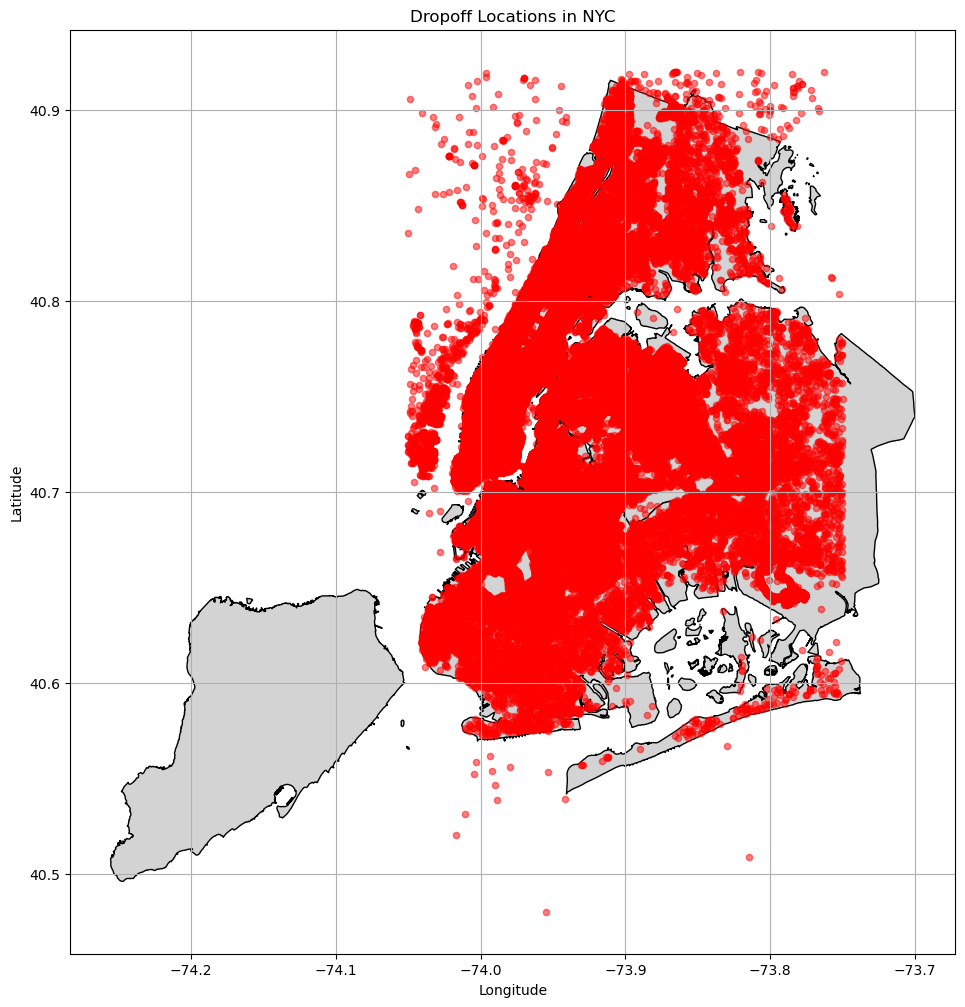

In [8]:
gdf = gpd.GeoDataFrame(dataset, geometry=gpd.points_from_xy(dataset['dropoff_longitude'], dataset['dropoff_latitude']), crs='EPSG:4326')

nyc_path = get_path('nybb')
nyc = gpd.read_file(nyc_path)
nyc = nyc.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12, 12))
nyc.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.5)
plt.title('Dropoff Locations in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

# Getting the Manhattan Distance

New York is designed with grid-like road layouts, thus we can use the Manhattan Distance formula to get an approximate distance between the point of origin and the destination a taxi might take. 

### The Manhattan Distance(in miles) is as follows: 

Let two points be:

- (phi1, lambda1): latitude and longitude of the origin(pickup) point.
- (phi2, lambda2): latitude and longitude of the destination(drop-off) point.

Approximation for Conversion to Miles:
- 1 degree of latitude ≈ 69.0 miles.
- 1 degree of longitude ≈ 69.0 × cos(phi_avg) miles, where phi_avg is the average of phi1 and phi2 in degrees.

Formula:

    $$
    \manhattan ≈ 69.0 × |phi2 - phi1| + (69.0 × cos((phi1 + phi2) / 2 in degrees)) × |lambda2 - lambda1|
    $$

Where: 
- phi1, phi2 are latitudes in degrees
- lambda1, lambda2 are longitudes in degrees
- cos() uses angle in degrees

In [9]:
def manhattan_distance(lat1, lon1, lat2, lon2):

    # Average latitude
    avg_lat = (lat1 + lat2) / 2.0
    # Approximate conversion factors
    lat_miles = 69.0
    lon_miles = 69.0 * np.cos(np.radians(avg_lat))

    d_lat = abs(lat2 - lat1) * lat_miles
    d_lon = abs(lon2 - lon1) * lon_miles

    return d_lat + d_lon

In [10]:
dataset['manhattan_distance'] = dataset.apply(
    lambda row: manhattan_distance(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)

dataset.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_day_of_the_week,manhattan_distance
0,2,1,-73.982155,40.767937,-73.964630,40.765602,455,17,0,1.076908
1,1,1,-73.980415,40.738564,-73.999481,40.731152,663,0,6,1.508262
2,2,1,-73.979027,40.763939,-74.005333,40.710087,2124,11,1,5.091137
3,2,1,-74.010040,40.719971,-74.012268,40.706718,429,19,2,1.030921
4,2,1,-73.973053,40.793209,-73.972923,40.782520,435,13,5,0.744302


# Creating Zones from Latitude & Longitutde using K-Means Clustering

To reduce longitude and latitude noise in our models, we will cluster that data into zones. This is similar to how cities group neighborhoods and zip codes. Using K-Means Clustering, we will transform the geographic coordinates into usable data for our models. 

In [11]:
# Zone clustering using KMeans
pickup_coords = dataset[['pickup_latitude', 'pickup_longitude']]
dropoff_coords = dataset[['dropoff_latitude', 'dropoff_longitude']]

n_clusters = 40

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pickup_zones = kmeans.fit_predict(pickup_coords)
dropoff_zones = kmeans.fit_predict(dropoff_coords)

dataset.loc[pickup_coords.index, 'pickup_zone'] = pickup_zones
dataset.loc[dropoff_coords.index, 'dropoff_zone'] = dropoff_zones

dataset.head()

/Users/wriosmar/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/wriosmar/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_day_of_the_week,manhattan_distance,pickup_zone,dropoff_zone
0,2,1,-73.982155,40.767937,-73.964630,40.765602,455,17,0,1.076908,8.0,0.0
1,1,1,-73.980415,40.738564,-73.999481,40.731152,663,0,6,1.508262,21.0,25.0
2,2,1,-73.979027,40.763939,-74.005333,40.710087,2124,11,1,5.091137,39.0,9.0
3,2,1,-74.010040,40.719971,-74.012268,40.706718,429,19,2,1.030921,24.0,9.0
4,2,1,-73.973053,40.793209,-73.972923,40.782520,435,13,5,0.744302,28.0,5.0


In [12]:
m = fm.Map(location=[40.7128, -74.0060], zoom_start=11)

for zone_id, center in enumerate(kmeans.cluster_centers_):
    fm.CircleMarker(
        location=[center[0], center[1]],
        radius=5,
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"Zone {zone_id}",
        icon=fm.Icon(color='blue', icon='info-sign')
    ).add_to(m)

m

# Final Dataset for our Model

In [13]:
clean_dataset = dataset.drop(columns=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])

clean_dataset.head()

,vendor_id,passenger_count,trip_duration,pickup_hour,pickup_day_of_the_week,manhattan_distance,pickup_zone,dropoff_zone
0,2,1,455,17,0,1.076908,8.0,0.0
1,1,1,663,0,6,1.508262,21.0,25.0
2,2,1,2124,11,1,5.091137,39.0,9.0
3,2,1,429,19,2,1.030921,24.0,9.0
4,2,1,435,13,5,0.744302,28.0,5.0


# Additional Visualizations

In [14]:
clean_dataset['passenger_count'].value_counts()

passenger_count
1    1029403
2     209318
5      77814
3      59665
6      48170
4      28265
0         59
7          1
8          1
Name: count, dtype: int64

# Random Forest Regression

- Use RMSE or MAE to evaluate performance

# Gradient Boosting Model (XGBoost)

# Deep Learning

# Results